In [377]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from math import sqrt



### Creación de la conexión a la base de datos para consultar la tabla "Player_Attributes"

In [378]:
##Conexion con sqlite
conn = sqlite3.connect("datasets/european_soccer_players.sqlite")

<code>
    Para incrementear precisión que obtuvimos originalmente y disminuir la raíz cuadrada del Error Cuadrático Medio.

    Segmente más los datos, a modo de obtener unicamente los datos por cada jugador y por un año especifico. Ya que, de momento no conocemos si para obtener el "overall_rating" se calculó como lo hariamos nosotros. No tenemos esa certeza, por lo que tomamos los ultimos registros del ultimo año disponible 2016

</code>

In [379]:
df = pd.read_sql_query('SELECT * FROM ( SELECT pa.*, ROW_NUMBER() OVER ( PARTITION BY player_fifa_api_id ORDER BY date DESC ) AS rn FROM Player_Attributes pa )WHERE rn = 1 and strftime("%Y", date) = "2016"', 
        conn)

df.head()

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,rn
0,64695,2,39357,2016-05-12 00:00:00,69.0,69.0,left,medium,high,75.0,...,50.0,70.0,69.0,69.0,14.0,5.0,15.0,10.0,12.0,1
1,83323,27,30630,2016-04-14 00:00:00,71.0,71.0,right,medium,low,80.0,...,66.0,35.0,34.0,30.0,9.0,6.0,13.0,16.0,7.0,1
2,68043,58,30668,2016-03-10 00:00:00,68.0,68.0,right,medium,medium,65.0,...,55.0,68.0,73.0,68.0,7.0,13.0,16.0,8.0,7.0,1
3,50294,80,24217,2016-03-10 00:00:00,74.0,74.0,left,medium,medium,78.0,...,85.0,64.0,66.0,65.0,7.0,11.0,7.0,14.0,8.0,1
4,63516,164,27731,2016-05-12 00:00:00,73.0,73.0,right,medium,high,71.0,...,67.0,65.0,73.0,69.0,5.0,15.0,7.0,6.0,13.0,1


In [380]:
df.shape

(5583, 43)

In [381]:
df.columns

Index(['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating',
       'potential', 'preferred_foot', 'attacking_work_rate',
       'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes', 'rn'],
      dtype='str')

### De todas las columnas, determinaremos cuáles se usarán como features para alimentar al modelo

In [382]:
features = [ 'potential', 'crossing', 'finishing', 'heading_accuracy','short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy','long_passing', 'ball_control', 'acceleration', 
            'sprint_speed','agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina','strength', 'long_shots', 'aggression', 'interceptions', 'positioning','vision', 'penalties', 
            'marking', 'standing_tackle', 'sliding_tackle','gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning','gk_reflexes' ]

### Selecionamos el tarjet

In [383]:
target = [ 'overall_rating' ]

In [384]:
df = df.dropna()

### Separamos las caracteristicas y el target en x e y

In [385]:
x = df[ features ]
y = df[ target ]

### Mostrar el contenido de una fila del conjunto X

In [386]:
x.iloc[2000]

potential             73.0
crossing              67.0
finishing             61.0
heading_accuracy      36.0
short_passing         66.0
volleys               49.0
dribbling             76.0
curve                 64.0
free_kick_accuracy    61.0
long_passing          66.0
ball_control          75.0
acceleration          79.0
sprint_speed          73.0
agility               80.0
reactions             66.0
balance               82.0
shot_power            63.0
jumping               56.0
stamina               64.0
strength              60.0
long_shots            55.0
aggression            28.0
interceptions         49.0
positioning           81.0
vision                71.0
penalties             50.0
marking               37.0
standing_tackle       32.0
sliding_tackle        23.0
gk_diving             12.0
gk_handling           16.0
gk_kicking            16.0
gk_positioning         7.0
gk_reflexes           15.0
Name: 2000, dtype: float64

In [387]:
x.head()

,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,69.0,75.0,50.0,59.0,71.0,58.0,73.0,65.0,60.0,69.0,...,66.0,50.0,70.0,69.0,69.0,14.0,5.0,15.0,10.0,12.0
1,71.0,80.0,64.0,41.0,77.0,75.0,79.0,84.0,77.0,69.0,...,74.0,66.0,35.0,34.0,30.0,9.0,6.0,13.0,16.0,7.0
2,68.0,65.0,22.0,67.0,64.0,55.0,68.0,52.0,42.0,66.0,...,61.0,55.0,68.0,73.0,68.0,7.0,13.0,16.0,8.0,7.0
3,74.0,78.0,68.0,43.0,80.0,69.0,75.0,81.0,80.0,80.0,...,77.0,85.0,64.0,66.0,65.0,7.0,11.0,7.0,14.0,8.0
4,73.0,71.0,59.0,68.0,77.0,68.0,66.0,58.0,54.0,77.0,...,77.0,67.0,65.0,73.0,69.0,5.0,15.0,7.0,6.0,13.0


In [388]:
y.head()

,overall_rating
0,69.0
1,71.0
2,68.0
3,74.0
4,73.0


### Muestreo de los valores de la feature "reactions" para cada jugador

In [389]:
x['reactions']

0       69.0
1       59.0
2       64.0
3       73.0
4       69.0
        ... 
5578    50.0
5579    48.0
5580    60.0
5581    48.0
5582    54.0
Name: reactions, Length: 5581, dtype: float64

### Imprimir la relacion existente entre la feature "reactions" y el target "overall_rating"

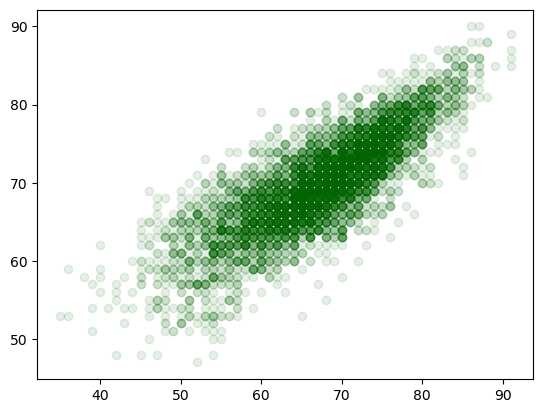

In [390]:
plt.scatter( x.reactions, y.overall_rating, c=['darkgreen'], label='Datos', alpha=0.1 )

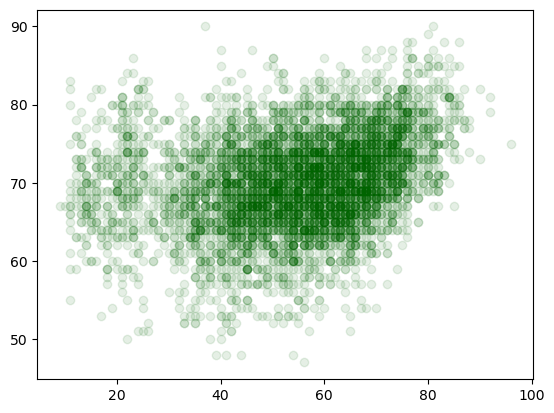

In [391]:
plt.scatter( x.penalties, y.overall_rating, c=['darkgreen'], label='Datos', alpha=0.1 )


### Separación de los datos en training y test datasets

<code>
    Para incrementear precisión que obtuvimos originalmente de la precisión y disminuir la raíz cuadrada del Error Cuadrático Medio.

    En este paso, no decidí como se segmentaría la información deje que el método lo definiciera por si solo. Lo que da como resultado, que para el entrenamiento se uso un 75% de la información con respecto al hecho en clase.


    Ya que realicé una prueba usando un 90% de la información para el conjunto de entrenamiento, y dio un resultado menor al obtenido con los parámetros obtenidos con el 75%

</code>

In [392]:
xTrain, xTest, yTrain, yTest = train_test_split( x, y, random_state = 324  ) 


print("Tamaño del conjunto de datos de entrenamiento:", len(xTrain))
print("Tamaño del conjunto de datos de pruebas:", len(xTest))

Tamaño del conjunto de datos de entrenamiento: 4185
Tamaño del conjunto de datos de pruebas: 1396


### Utilizar un escalado estándar
Para que los datos de cada feature se acople a un rango y se eviten los sesgos de un feature con valores muy altos que puedan influir de mas en el target

In [393]:
scale = preprocessing.StandardScaler()

### Entrenar con los datos escalados

In [394]:
scale.fit(xTrain)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [395]:
xTrain = scale.transform(xTrain)

### Imprimir los nuevos valores mínimo y máximo de las features de entrenamiento

In [396]:
xTrain.min()

np.float64(-4.085602235237917)

In [397]:
xTrain.max()

np.float64(5.057711733486812)

### Creamos una instancia del modelo de Regresión lineal de Sckit Learn

In [398]:
regresor = LinearRegression()


### Ajustando el modelo a los datos de entrenamiento

In [399]:
regresor.fit(xTrain, yTrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Realizar una predicción usando el conjunto de datos Test

In [400]:
# Escalar los valores de testeo para que coincidan con los de entrenamiento

xTest = scale.transform(xTest)

In [401]:
#hacer una prediccion del valore de salida, pasandole los valores de prueba
yPrediccion = regresor.predict( xTest )

In [402]:
#Obtener la diferencia que hay entre los valores de salida predichos contra los valores de salida reales

yResult = yPrediccion - yTest

In [403]:
yResult

,overall_rating
4681,-1.484291
5464,4.856074
3164,2.196389
3375,0.351132
1182,0.424540
...,...
4763,-2.163732
777,-0.686145
1466,-1.593832
4690,-0.762815


### Calcular la raíz cuadrada del error cuadrático medio

In [404]:
RMSE = sqrt( mean_squared_error( y_true=yTest, y_pred=yPrediccion ) )
RMSE 


2.200575365265004

### Mostrar la precisión que obtuvo el modelo al predecir con los valores de prueba

In [405]:
regresor.score(xTest, yTest)

0.8703936032363598

### Mostrar cual es el valor de cada w que se aplicó a cada feature (w * x) para que al sumar todos los productos nos de el puntaje de cada jugador

In [406]:
regresor.coef_

array([[ 2.52559472e+00,  4.11512725e-01,  2.44858628e-01,
         9.24816239e-01,  2.80223151e-01,  1.14184670e-01,
        -6.83711476e-01,  3.88396448e-01,  1.72942472e-01,
         1.63638050e-01,  1.86534617e+00, -9.73011337e-02,
         1.93091565e-01,  1.62475431e-01,  2.13300129e+00,
         9.10780093e-03,  1.81882055e-01,  8.71584000e-02,
         3.32260953e-04,  5.67902270e-01, -1.60700806e-01,
         3.08322419e-01,  3.32443802e-01, -6.42358432e-01,
        -3.75857316e-02,  1.10248571e-01,  4.18482773e-01,
        -1.94437131e-01, -3.40029829e-01,  7.67160628e-01,
         6.23853456e-01,  2.66219439e-01,  5.90920862e-01,
         8.40112335e-01]])

In [407]:
regresor.intercept_

array([70.01863799])

# Tarea Sección


<code>
Resultados con la consulta aplicada y usando un 90% de la info como datos de entrenamiento.Resultados obtenidos

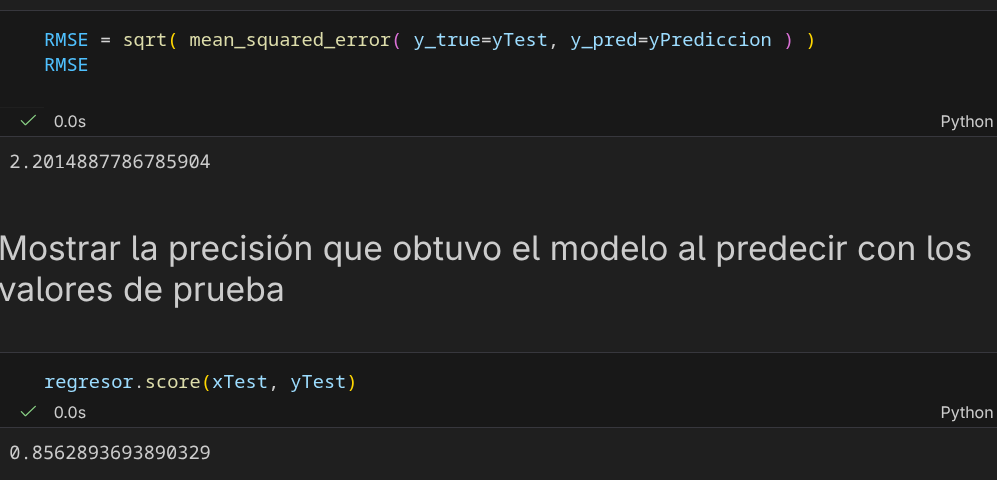

</code>

<code>
Resultados con la consulta aplicada, y con el 75% de la información para usar como datos de entrenamiento. Pasamos de un RMSE de 2.805 a 2.200 y de un score de 0.84 a 0.87


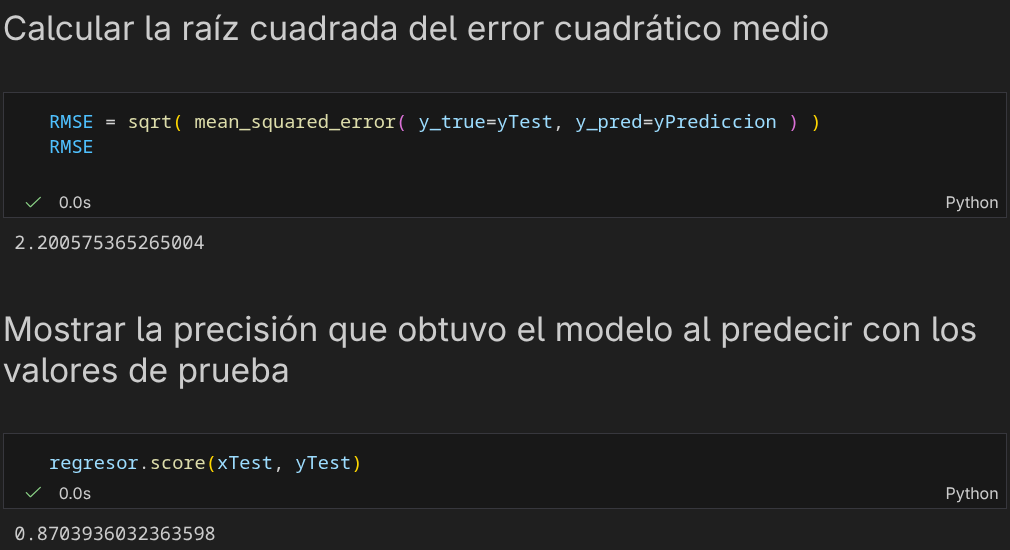
</code>